1. Exploração e Análise dos Dados

Primeiro, vamos carregar o conjunto de dados e realizar uma exploração inicial para entender a estrutura dos dados, incluindo a distribuição das variáveis e a relação entre as características e o preço de venda.

2. Divisão do Conjunto de Dados
Depois de entender a distribuição dos dados, dividiremos o conjunto em conjuntos de treinamento e teste. Isso nos permitirá treinar o modelo em um subconjunto dos dados e avaliar seu desempenho em um conjunto separado.

3. Desenvolvimento do Modelo de Regressão Linear Multivariada
Com os dados prontos, desenvolveremos o modelo de Regressão Linear Multivariada. Utilizaremos as características fornecidas (tamanho da casa, número de quartos, número de banheiros, idade da casa, e proximidade ao centro) como variáveis independentes e o preço de venda como a variável dependente.

4. Avaliação do Modelo
Após o desenvolvimento do modelo, avaliaremos seu desempenho utilizando a métrica de erro quadrático médio (RMSE). O objetivo é garantir que o RMSE esteja abaixo de 69.000.

5. Previsão de Preços de Venda
Finalmente, utilizaremos o modelo para prever o preço de venda de novas casas com base nas características fornecidas.

In [2]:
# Importação das bibliotecas
import pandas as pd

In [3]:
# Carregamento da base de dados
house_prices = pd.read_csv (r"C:\Users\steph\OneDrive\FIAP\DATA PROCESSING WITH PYTHON\Projeto Integrado\house_prices.csv")
house_prices.head (15)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
5,7237550310,20140512T000000,1225000.0,4,4.50,5420,101930,1.0,0,0,...,11,3890,1530,2001,0,98053,47.6561,-122.005,4760,101930
6,1321400060,20140627T000000,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
7,2008000270,20150115T000000,291850.0,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711
8,2414600126,20150415T000000,229500.0,3,1.00,1780,7470,1.0,0,0,...,7,1050,730,1960,0,98146,47.5123,-122.337,1780,8113
9,3793500160,20150312T000000,323000.0,3,2.50,1890,6560,2.0,0,0,...,7,1890,0,2003,0,98038,47.3684,-122.031,2390,7570


id: Um identificador único para cada casa

date: A data da venda

price: O preço de venda da casa

bedrooms: O número de quartos na casa

bathrooms: O número de banheiros na casa

sqft_living: A área da casa 

sqft_lot: O tamanho do lote

floors: O número de andares na casa

waterfront: Se a casa tem frente para o mar (1) ou não (0)

view: A qualidade da vista da casa, numerada de 0 a 4 

condition: A condição da casa, numerada de 1 a 5 

grade: A qualidade da casa, numerada de 1 a 13

sqft_above: A área habitável acima do solo

sqft_basement: A área do porão

yr_built: O ano em que a casa foi construída

yr_renovated: O ano em que a casa foi renovada pela última vez

zipcode: O código postal da casa

lat: A latitude da casa

long: A longitude da casa

sqft_living15: A área habitável média das 15 casas mais próximas

sqft_lot15: O tamanho médio do lote das 15 casas mais próximas

Entendendo os dados

In [4]:
house_prices.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

R.: sem valor nulo

Estatísticas Descritivas para colunas númericas de um DF
- Count: o número de valores não nulos
- Mean: a média dos valores
- STD: desvio padrão (dispersão dos valores em torno da média)
- MIN: o valor mínimo
- 25%: o primeiro quartil
- 50%: a mediana ou segundo quartil (Q2) (valor abaixo do qual 50% dos dados se encontram)
- 75%: o terceiro quartil (Q3) (valor abaixo do qual 75% dos dados se encontram)
- MAX: o valor máximo

In [5]:
house_prices.describe ()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


price
media: 540088
valor min: 75000
valor max: 7700000

bedrooms
media: 3,37
min: 0
max: 33 -- outlier?

bathrooms
media: 2,11
min: 0
max: 33 

sqft_living
media: 2079
min: 290
max: 13540

sqft_lot
media: 15107
min: 520
max: 1651359

floors 
media: 1,49
min: 1
max: 3,5 -- 3,5 andares?

waterfront 
media:0,0075 -- pouca casa em frente do mar
min: 0
max: 1

view 
media: 0,23
min: 0
max: 4 

condition (da casa?)
media: 3,41
min: 1
max: 5

grade 
media: 7,66 -- então maioria tem qualidade boa?
min: 1
max: 13

sqft_above 
media: 1788
min: 290
max: 9410

sqft_basement 
media: 291,5
min: 0 -- tem casa que não tem porão
max: 4.280

yr_renovated (year/renovação)
media: 84,4
min: 0 
max: 2015

zipcode 
media: 98078 -- muitos zipcodes em áreas geográficas?
min: 98001
max: 98199

lat (latitude?) 
media: 47,56 
min: 47,56 
max: 47,78

long (Longitude?)
media: 122,21
min: -122,52
max: -121,32

sqft_living15 
media: 1986 
min: 399
max: 6210

sqft_lot15 
media: 12768
min: 651 
max: 871200 -- outlier?


tirando o id

----------

Análise exploratória

<Axes: >

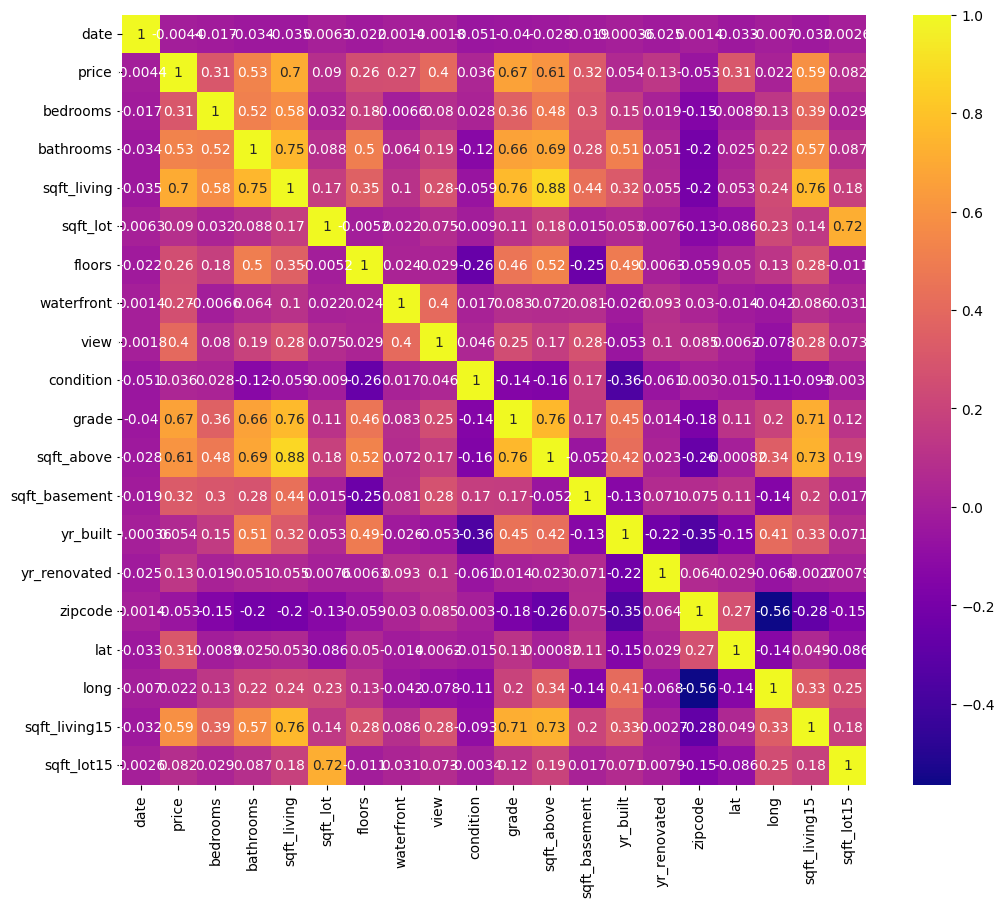

In [33]:
house_prices['date']=pd.to_datetime(house_prices['date'])
house_prices
correlation = house_prices.corr()
plt.subplots(figsize = (12, 10))
sns.heatmap(correlation, annot=True, cmap='plasma')

In [7]:
# contagem de andar por casa
house_prices['floors'].value_counts().to_frame()

,count
floors,
1.0,10680
2.0,8241
1.5,1910
3.0,613
2.5,161
3.5,8


<Axes: xlabel='bedrooms'>

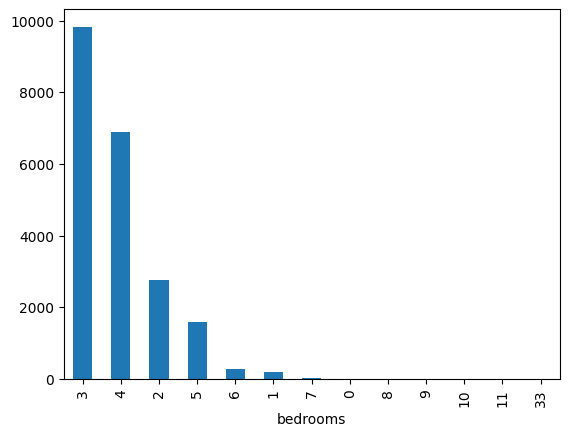

In [36]:
house_prices['bedrooms'].value_counts().plot(kind='bar')

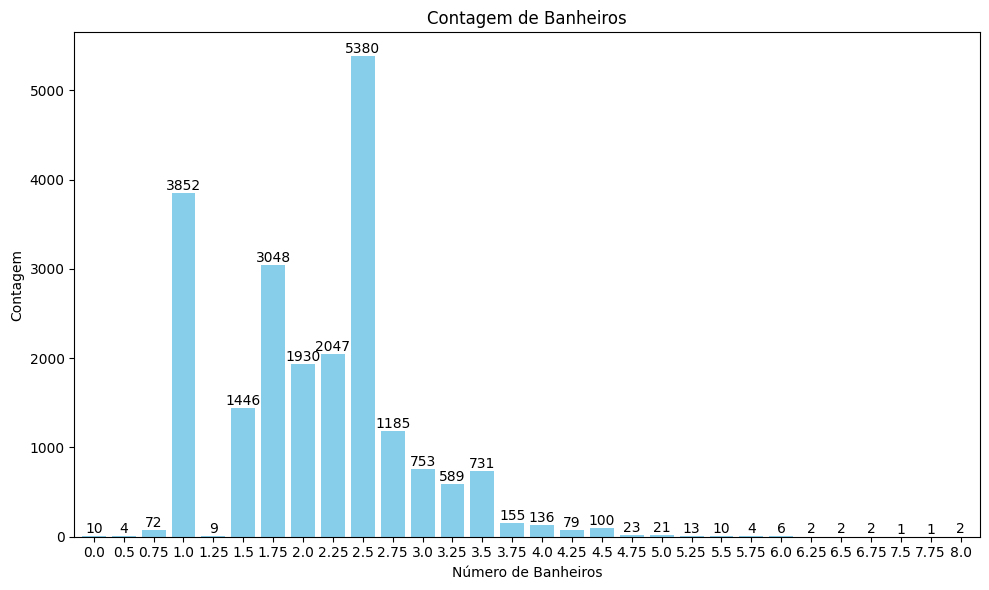

In [46]:
import matplotlib.pyplot as plt

# Contar os valores de 'bathrooms'
bathroom_counts = house_prices['bathrooms'].value_counts()

# Ordenar pelo número de banheiros
bathroom_counts = bathroom_counts.sort_index()

# Configurar o tamanho do gráfico para melhor visualização
plt.figure(figsize=(10, 6))

# Plotar o gráfico de barras
bathroom_counts.plot(kind='bar', color='skyblue', width=0.8)

# Adicionar título e rótulos
plt.title('Contagem de Banheiros')
plt.xlabel('Número de Banheiros')
plt.ylabel('Contagem')

# Adicionar rótulos às barras
for index, value in enumerate(bathroom_counts):
    plt.text(index, value + 0.5, str(value), ha='center', va='bottom')

# Manter os rótulos do eixo x horizontais
plt.xticks(rotation=0)

# Mostrar o gráfico
plt.tight_layout()  # Ajusta o layout para evitar sobreposição
plt.show()


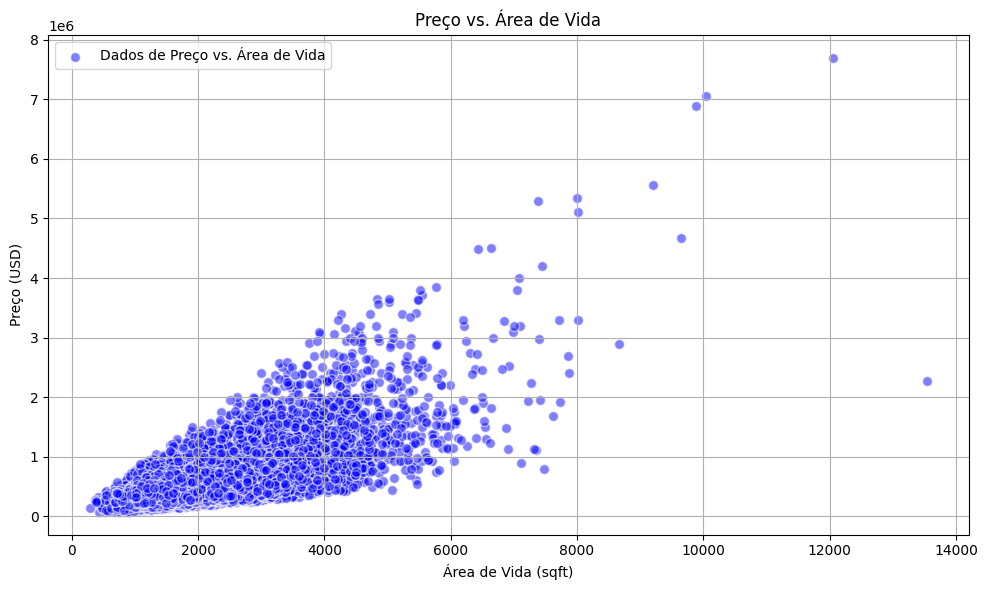

In [48]:
import matplotlib.pyplot as plt

# Criar o gráfico de dispersão
plt.figure(figsize=(10, 6))
plt.scatter(house_prices['sqft_living'], house_prices['price'], alpha=0.5, color='blue', edgecolors='w', s=50)

# Adicionar título e rótulos
plt.title('Preço vs. Área de Vida')
plt.xlabel('Área de Vida (sqft)')
plt.ylabel('Preço (USD)')

# Adicionar uma legenda
plt.legend(['Dados de Preço vs. Área de Vida'], loc='upper left')

# Melhorar o layout
plt.grid(True)  # Adicionar uma grade para melhor visualização
plt.tight_layout()  # Ajustar o layout para evitar sobreposição

# Mostrar o gráfico
plt.show()


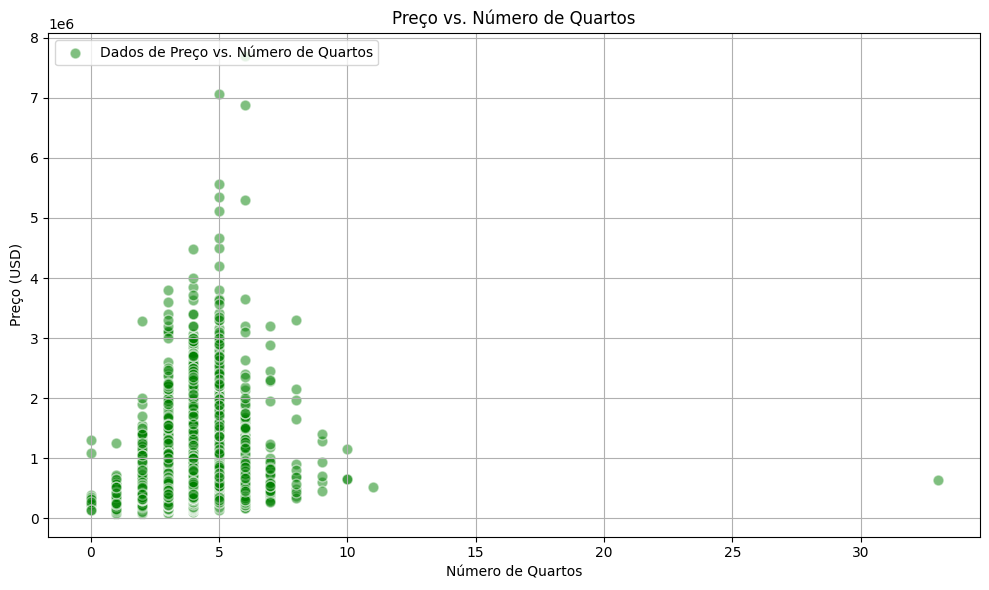

In [50]:
import matplotlib.pyplot as plt

# Criar o gráfico de dispersão
plt.figure(figsize=(10, 6))
plt.scatter(house_prices['bedrooms'], house_prices['price'], alpha=0.5, color='green', edgecolors='w', s=60)

# Adicionar título e rótulos
plt.title('Preço vs. Número de Quartos')
plt.xlabel('Número de Quartos')
plt.ylabel('Preço (USD)')

# Adicionar uma legenda
plt.legend(['Dados de Preço vs. Número de Quartos'], loc='upper left')

# Melhorar o layout
plt.grid(True)  # Adicionar uma grade para melhor visualização
plt.tight_layout()  # Ajustar o layout para evitar sobreposição

# Mostrar o gráfico
plt.show()


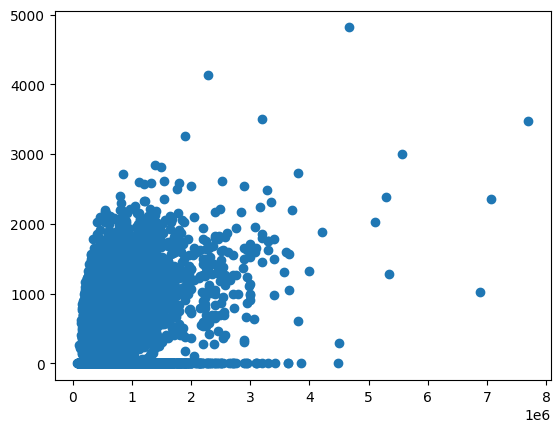

In [52]:
plt.scatter(house_prices.price,house_prices.sqft_basement)

In [ ]:
plt.scatter(house_prices.floors,house_prices.price)

In [ ]:
plt.scatter(house_prices.waterfront,house_prices.price)

In [ ]:
plt.scatter(house_prices.condition,house_prices.price)

In [ ]:
plt.scatter(house_prices.zipcode,house_prices.price)

In [ ]:
plt.scatter(house_prices.lat,house_prices.price)

In [ ]:
plt.scatter(house_prices.yr_renovated,house_prices.price)

In [ ]:
plt.scatter(house_prices.yr_built,house_prices.price)

In [ ]:
house_prices.drop(columns=['date','long','id','floors','zipcode','sqft_lot','sqft_lot15'],inplace=True)

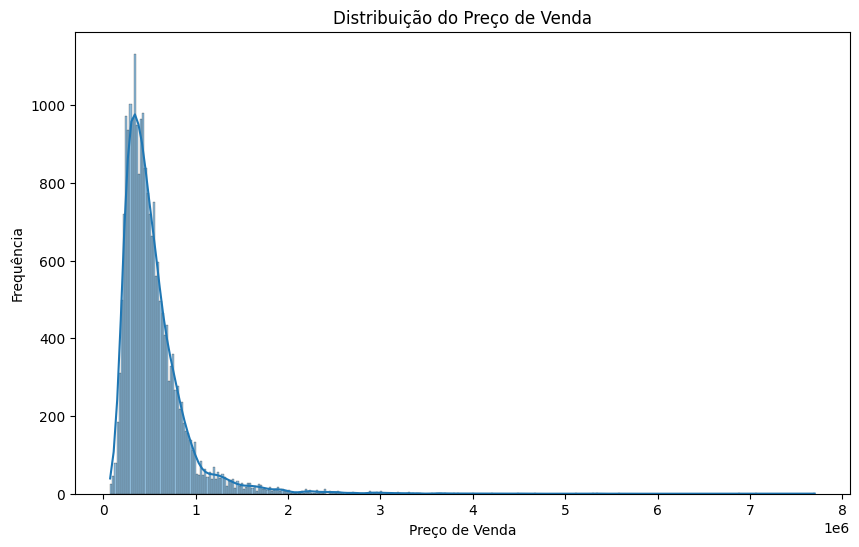

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Verificar a distribuição do preço de venda
plt.figure(figsize=(10, 6))
sns.histplot(house_prices['price'], kde=True)  
plt.title('Distribuição do Preço de Venda')
plt.xlabel('Preço de Venda')
plt.ylabel('Frequência')
plt.show()



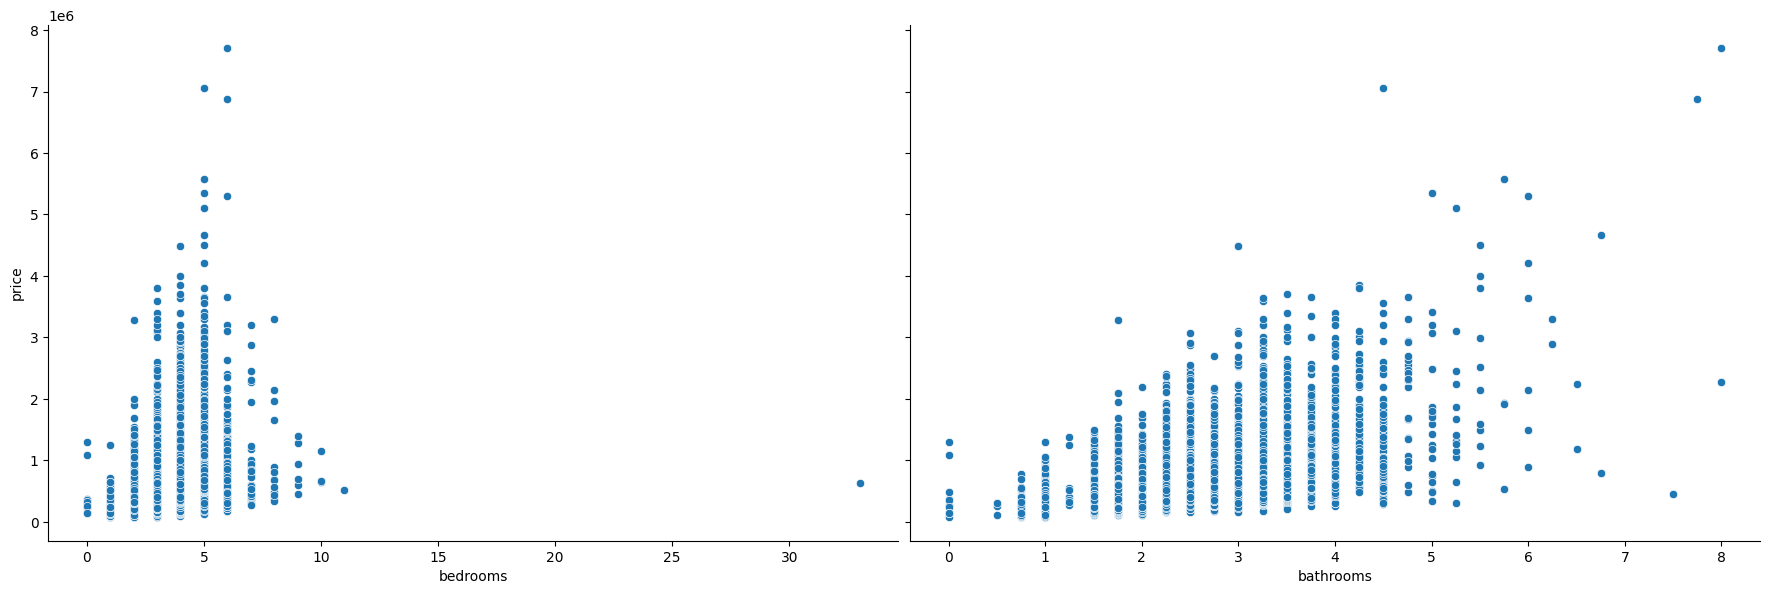

In [27]:

# Criar gráficos de dispersão para visualizar a relação entre as variáveis independentes e o preço de venda
sns.pairplot(house_prices, x_vars=['bedrooms', 'bathrooms'], y_vars='price', height=6, aspect=1.5)
plt.show()
#'sqft_living', 'yr_built', 'zipcode'

considerações

bedrooms: há uma tendência de que qtd de quarto parece ser fator determinante qto ao preço, mas tem variações

bathrooms: correlação positiva também

sqft_living: quanto maior a área, maior o preço de venda - fator determinante no preço


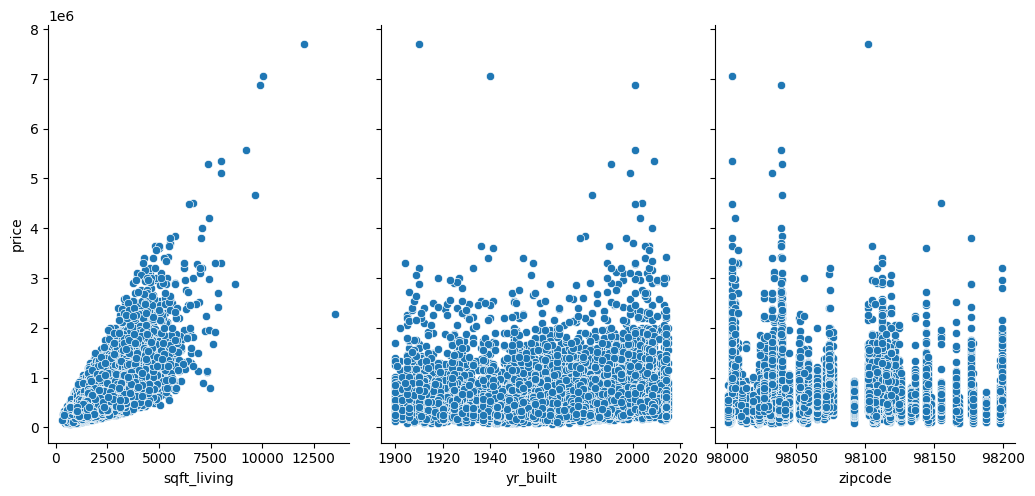

In [28]:
# Criar gráficos de dispersão para visualizar a relação entre as variáveis independentes e o preço de venda
sns.pairplot(house_prices, x_vars=['sqft_living', 'yr_built', 'zipcode'], y_vars='price', height=5, aspect=0.7)
plt.show()


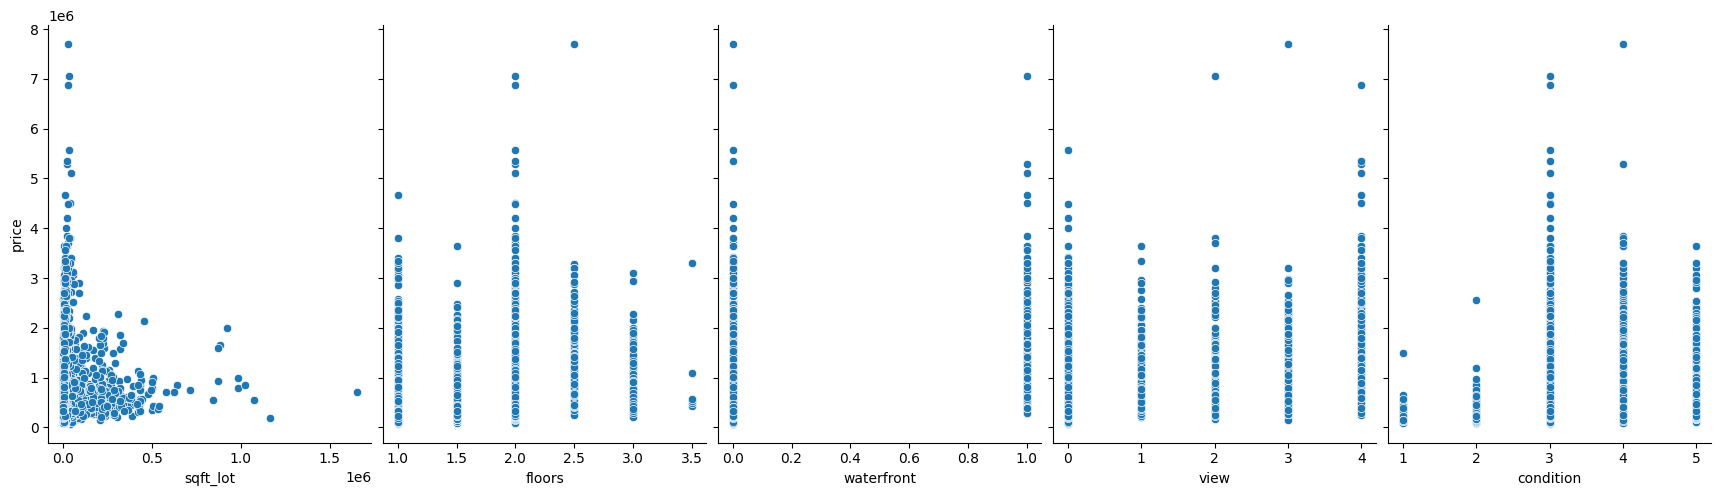

In [18]:
# Criar gráficos de dispersão para visualizar a relação entre as variáveis independentes e o preço de venda
sns.pairplot(house_prices, x_vars=['sqft_lot', 'floors', 'waterfront', 'view', 'condition'], y_vars='price', height=5, aspect=0.7)
plt.show()

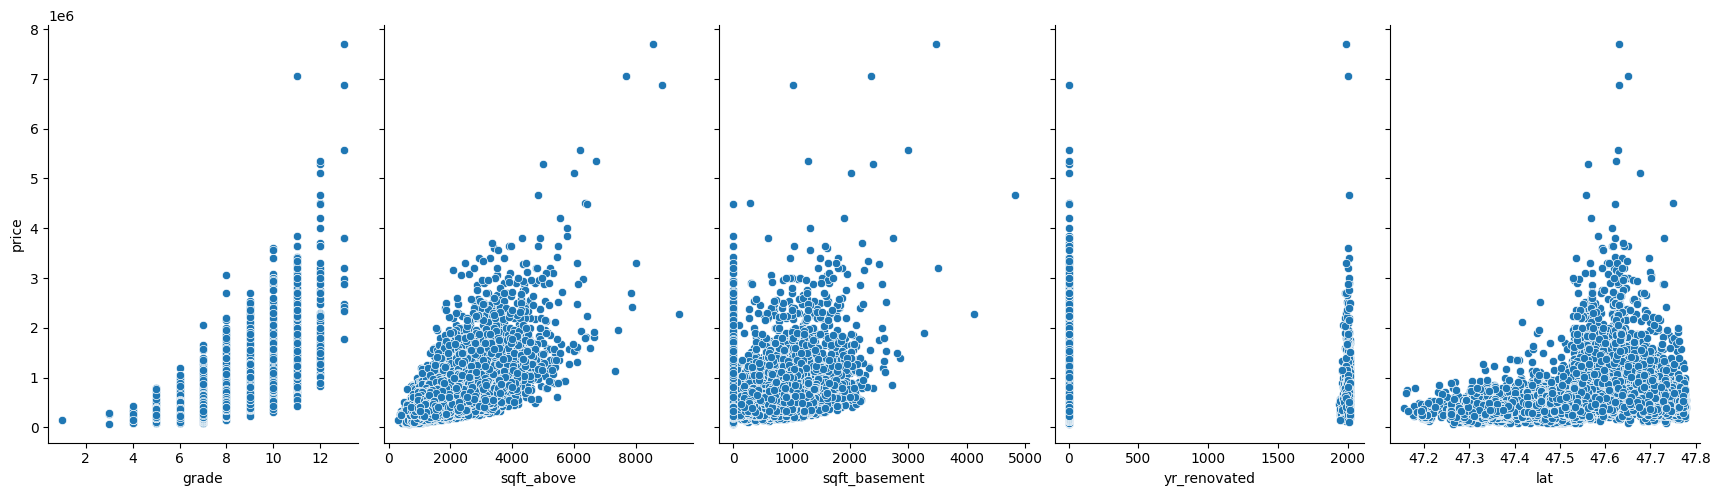

In [19]:
# Criar gráficos de dispersão para visualizar a relação entre as variáveis independentes e o preço de venda
sns.pairplot(house_prices, x_vars=['grade', 'sqft_above', 'sqft_basement', 'yr_renovated', 'lat'], y_vars='price', height=5, aspect=0.7)
plt.show()

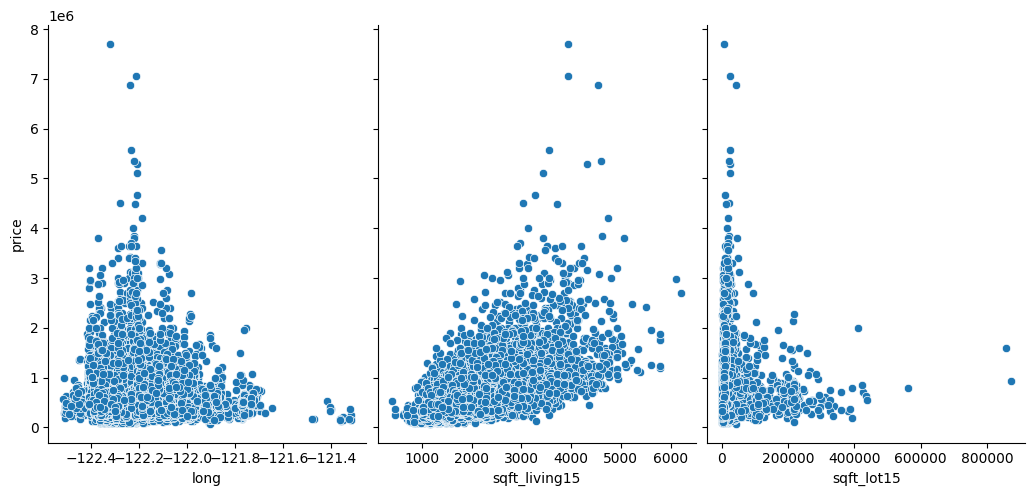

In [20]:
# Criar gráficos de dispersão para visualizar a relação entre as variáveis independentes e o preço de venda
sns.pairplot(house_prices, x_vars=['long', 'sqft_living15', 'sqft_lot15'], y_vars='price', height=5, aspect=0.7)
plt.show()

considerações
bedrooms: qtd de quarto não parece ser fator determinante qto ao preço
bathrooms: correlação positiva, mas nem tanto
sqft_living: quanto maior a área, maior o preço de venda - fator determinante no preço


C:\Users\steph\AppData\Local\Temp\ipykernel_9932\4024233524.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=house_prices['waterfront'], y=house_prices['price'], palette="Set2") # paleta de cores para diferenciar as categorias


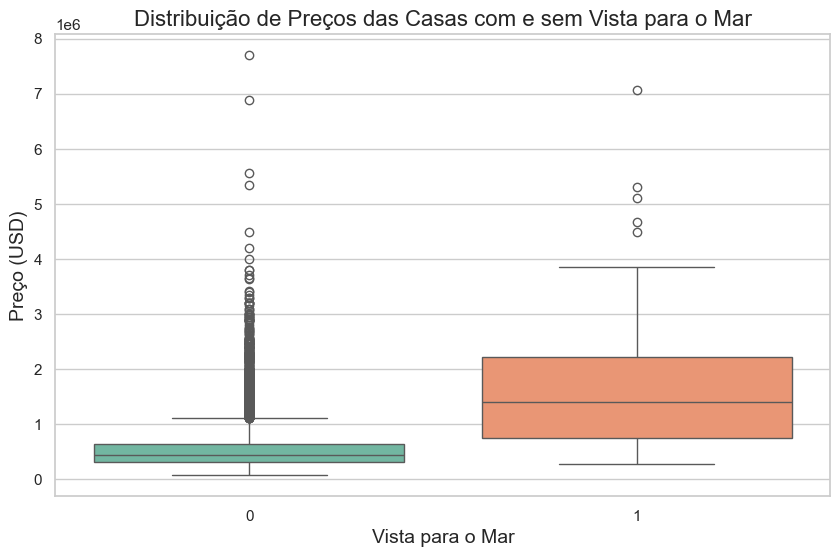

In [ ]:
# outliers - casas de frente para a água têm maiores preços?
sns.set(style= 'whitegrid') # fundo branco

# Criação do gráfico de caixa
plt.figure(figsize=(10,6))
sns.boxplot(x=house_prices['waterfront'], y=house_prices['price'], palette="Set2") # paleta de cores para diferenciar as categorias

# Títulos e rótulos dos eixos
plt.title("Distribuição de Preços das Casas com e sem Vista para o Mar", fontsize=16)
plt.xlabel("Vista para o Mar", fontsize=14)
plt.ylabel("Preço (USD)", fontsize=14)

# Mostrar o gráfico
plt.show()

# 1 - sim; 0 - não

R.: sem vista para o mar (0) tem preços mais baixos e menor variação ($) - poucos outliers?

    com vista para o mar (1) tem preços mais altos e maior variação ($) - mais outliers? o que poderia significar casas com preços bem mais altos que a maioria?

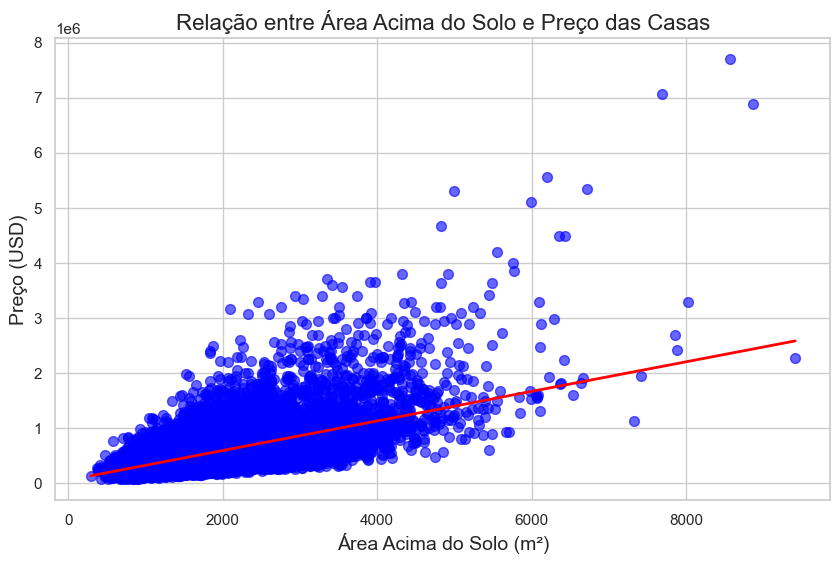

In [ ]:
# linha de regressão - m² e solo das casas $
# Configuração do estilo do gráfico
sns.set(style="whitegrid")

# Criação do gráfico de regressão
plt.figure(figsize=(10,6))
sns.regplot(
    x=house_prices['sqft_above'],
    y=house_prices['price'],
    data=house_prices,
    scatter_kws={'s':50, 'color':'blue', 'alpha':0.6},  # Personaliza os pontos de dispersão
    line_kws={'color':'red', 'lw':2},  # Personaliza a linha de regressão
    ci=None  # Remove a faixa de confiança
)

# Títulos e rótulos dos eixos
plt.title("Relação entre Área Acima do Solo e Preço das Casas", fontsize=16)
plt.xlabel("Área Acima do Solo (m²)", fontsize=14)
plt.ylabel("Preço (USD)", fontsize=14)

# Mostrar o gráfico
plt.show()

linha de regressão parece mostrar que casas com maior m² acima do solo tendem a ser mais caras

In [ ]:
# contém apenas as colunas numéricas 
num_house_prices = house_prices.select_dtypes(include=[np.number])
num_house_prices

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,360000.0,3,2.50,1530,1131,3.0,0,0,3,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,400000.0,4,2.50,2310,5813,2.0,0,0,3,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,402101.0,2,0.75,1020,1350,2.0,0,0,3,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,400000.0,3,2.50,1600,2388,2.0,0,0,3,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


----------------

In [ ]:
# dividir conjunto de dados em dois (conjunto de treinamento e conjunto de teste para avaliar performance - treinando em um, testando em outro)
from sklearn.model_selection import train_test_split
# para regressão linear - algoritmo de machine learning usado para modelar a relação entre uma variável dependente (target) e uma ou mais variáveis independentes (features)
from sklearn.linear_model import LinearRegression
# calcula o erro quadrático médio (MSE) - métrica comum para avaliar a performance de modelos de regressão, medindo a média dos quadrados das diferenças entre os valores previstos e reais. qt menor o MSE, melhor o modelo está se ajustando
from sklearn.metrics import mean_squared_error
# oferece suporte para arrays multidimensionais, funções matemáticas e estatísticas de alto desempenho e geração de números aleatórios
import numpy as np

escolha das colunas relevantes:
1. bedrooms (nº de quartos): variação de valor de acordo com o nº de quartos
2. bathrooms (nº de banheiros): variação de valor de acordo com a qtd de banheiros
3. sqft_living (área interna da casa em pés quadrados)
4. sqft_lot (tamanho do lote em pés quadrados): variação de valor de acordo com o tamanho e a localização do lote 
5. floors (número de andares): também pode influenciar o preço.
6. yr_built (ano de construção): O ano de construção pode influenciar o preço, pois casas mais novas ou bem mantidas tendem a ser mais valiosas. Além disso, o ano de construção pode ser um proxy para o estilo arquitetônico e a qualidade dos materiais usados.

--------------------------------------------------

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma do preço da casa

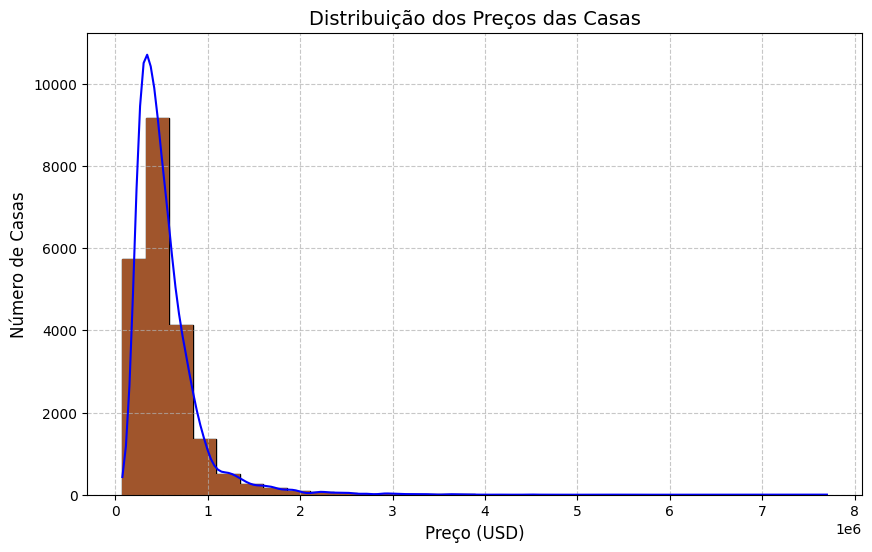

In [ ]:
# Define o tamanho da figura do gráfico
plt.figure(figsize=(10,6))
# Histograma dos preços das casas
plt.hist(house_prices["price"], bins=30, color="green")
# Linha de densidade para ajudar a visualizar a distribuição dos dados mais suavemente
sns.histplot(house_prices["price"], bins=30, color="blue", kde=True)
#  linhas de grade para ajudar a interpretar os dados mais facilmente.
plt.grid(True, linestyle='--', alpha=0.7)
# melhorando a interpretação com uma cor que oferece contraste
plt.hist(house_prices["price"], bins=30, color="#a0552c")  # Usando um verde mais suave
# Título do gráfico
plt.title("Distribuição dos Preços das Casas", fontsize = 14)
# Título do eixo X
plt.xlabel("Preço (USD)", fontsize = 12)
# Título do eixo Y
plt.ylabel("Número de Casas", fontsize = 12)
# Mostra o gráfico
plt.show()

Correlações

--------------

In [55]:
x = house_prices.drop(columns='price',axis=1)
y = house_prices['price']

In [56]:
x

,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,2014-10-13,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,2014-12-09,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,2015-02-25,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2014-12-09,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,2015-02-18,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,2014-05-21,3,2.50,1530,1131,3.0,0,0,3,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,2015-02-23,4,2.50,2310,5813,2.0,0,0,3,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,2014-06-23,2,0.75,1020,1350,2.0,0,0,3,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,2015-01-16,3,2.50,1600,2388,2.0,0,0,3,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [57]:
y

0        221900.0
1        538000.0
2        180000.0
3        604000.0
4        510000.0
           ...   
21608    360000.0
21609    400000.0
21610    402101.0
21611    400000.0
21612    325000.0
Name: price, Length: 21613, dtype: float64

In [63]:
print(x.dtypes)
print(y.dtypes)


date             datetime64[ns]
bedrooms                  int64
bathrooms               float64
sqft_living               int64
sqft_lot                  int64
floors                  float64
waterfront                int64
view                      int64
condition                 int64
grade                     int64
sqft_above                int64
sqft_basement             int64
yr_built                  int64
yr_renovated              int64
zipcode                   int64
lat                     float64
long                    float64
sqft_living15             int64
sqft_lot15                int64
dtype: object
float64


In [64]:
house_prices = house_prices.drop(columns=['date'])

In [65]:
x = house_prices[['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']]
y = house_prices['price']

In [66]:
x = x.apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(y, errors='coerce')

In [67]:
from sklearn.linear_model import LinearRegression
reg=LinearRegression()
reg.fit(x,y)


LinearRegression()

In [68]:
# Fazer previsões
predictions = reg.predict(x)

# Mostrar os coeficientes do modelo
print("Coeficientes:", reg.coef_)
print("Intercepto:", reg.intercept_)

Coeficientes: [-3.57665414e+04  4.11442785e+04  1.10442865e+02  1.28597869e-01
  6.68955012e+03  5.82960458e+05  5.28709424e+04  2.63856491e+04
  9.58904452e+04  7.07852244e+01  3.96576400e+01 -2.62022321e+03
  1.98125837e+01 -5.82419866e+02  6.02748226e+05 -2.14729828e+05
  2.16814005e+01 -3.82641850e-01]
Intercepto: 6690324.60308499


In [69]:
reg.score(x,y)

0.6997471890109155